# Lab 8: Enhanced Naive Bayes Classifier

**Dataset:** Play Tennis (weather.csv)

**Enhancements applied (theory-grounded):**
1. **Feature Selection via Mutual Information** — removes redundant features so CNB doesn't double-count correlated evidence
2. **Alpha Smoothing Tuning (Lidstone)** — grid search over $\alpha$ instead of default Laplace ($\alpha=1$) to avoid over-smoothing
3. **Probability Calibration (Platt Scaling)** — fixes CNB's tendency to push probabilities to extremes due to the independence assumption

### Imports
Import all required libraries — pandas for data handling, sklearn components for encoding, model training, tuning, calibration, and evaluation.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

---
## 1. Load Dataset
Read the 50-row Play Tennis CSV into a DataFrame for inspection and processing.

In [2]:
df = pd.read_csv('weather.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (50, 6)


,No,Outlook,Temperature,Humidity,Wind,Play Tennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes
5,6,Rain,Cool,Normal,Strong,No
6,7,Overcast,Cool,Normal,Strong,Yes
7,8,Sunny,Mild,High,Weak,No
8,9,Sunny,Cool,Normal,Weak,Yes
9,10,Rain,Mild,Normal,Weak,Yes


**Inference:** Dataset has 50 samples with 4 categorical features and a binary target (Yes: 34, No: 16) — moderately imbalanced toward Yes.

---
## 2. Separate Features and Target
Split the dataframe into feature matrix X (4 weather attributes) and target vector y (Play Tennis decision).

In [3]:
X = df[['Outlook', 'Temperature', 'Humidity', 'Wind']]
y = df['Play Tennis']

print('Target distribution:')
print(y.value_counts(), '\n')

Target distribution:
Play Tennis
Yes    34
No     16
Name: count, dtype: int64 



**Inference:** Yes appears roughly twice as often as No — accuracy baselines should be compared against a 68% majority-class dummy classifier.

---
## 3. Train/Test Split
Split data 70/30 with stratification to preserve the Yes/No ratio in both sets, ensuring representative evaluation.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 35, Test size: 15


**Inference:** 35 training and 15 test samples — a small test set typical of this toy dataset, so single-point accuracy shifts should be interpreted cautiously.

---
## 4. Encode Categorical Features
- **OrdinalEncoder** maps categories to integers (0,1,2) for CategoricalNB which expects ordinal input.
- **OneHotEncoder** creates binary columns per category for DT/LR, avoiding false ordinal relationships.
- **LabelEncoder** converts target labels (No/Yes) to 0/1.

In [5]:
ord_enc = OrdinalEncoder(dtype=np.int64)
X_train_ord = ord_enc.fit_transform(X_train)
X_test_ord = ord_enc.transform(X_test)

ohe = OneHotEncoder(sparse_output=False, dtype=np.int64)
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

feature_names = ['Outlook', 'Temperature', 'Humidity', 'Wind']
print(f'Target classes: {le.classes_.tolist()}')

Target classes: ['No', 'Yes']


**Inference:** OrdinalEncoder preserves the 4-feature structure while OneHotEncoder expands to 10 binary columns — appropriate for their respective model types.

---
## 5. Enhancement 1: Feature Selection via Mutual Information

**Theory:** CNB multiplies class-conditional probabilities $P(X|Y) = \prod P(x_i|Y)$. Correlated features double-count evidence, inflating probabilities and shifting decision boundaries. Mutual Information measures dependency between each feature and the target — low MI = weak signal = candidate for removal.

Compute MI scores, rank features, and test CNB with and without the weakest feature.

In [6]:
mi_scores = mutual_info_classif(X_train_ord, y_train_enc, discrete_features=True, random_state=42)

print('Mutual Information with target (Play Tennis):')
for name, score in sorted(zip(feature_names, mi_scores), key=lambda x: -x[1]):
    print(f'  {name:15s} {score:.4f}')

weakest_idx = int(np.argmin(mi_scores))
strongest_idx = [i for i in range(4) if i != weakest_idx]
print(f'\nWeakest feature: {feature_names[weakest_idx]} ({mi_scores[weakest_idx]:.4f})')

Mutual Information with target (Play Tennis):
  Outlook         0.1328
  Humidity        0.1265
  Temperature     0.0627
  Wind            0.0138

Weakest feature: Wind (0.0138)


**Inference:** Outlook (0.1328) and Humidity (0.1265) carry the most signal; Wind (0.0138) is nearly independent of the target and a candidate for removal.

In [7]:
cnb_all = CategoricalNB(alpha=1.0)
cnb_all.fit(X_train_ord, y_train_enc)
acc_all = accuracy_score(y_test_enc, cnb_all.predict(X_test_ord))

cnb_sel = CategoricalNB(alpha=1.0)
cnb_sel.fit(X_train_ord[:, strongest_idx], y_train_enc)
acc_sel = accuracy_score(y_test_enc, cnb_sel.predict(X_test_ord[:, strongest_idx]))

print(f'CNB with ALL features:      {acc_all:.4f}')
print(f'CNB without "{feature_names[weakest_idx]}":  {acc_sel:.4f}')
print(f'Difference: {acc_sel - acc_all:+.4f}')
if acc_sel >= acc_all:
    print('→ Dropping the weak feature simplifies the model with no accuracy loss.')
else:
    print('→ Keep all features — low-MI feature still contributes synergistically.')

CNB with ALL features:      0.8667
CNB without "Wind":  0.8667
Difference: +0.0000
→ Dropping the weak feature simplifies the model with no accuracy loss.


**Inference:** Removing Wind leaves accuracy unchanged at 86.67% — confirms it contributes negligible predictive value and can be dropped for a simpler model.

---
## 6. Enhancement 2: Alpha Smoothing Tuning (Lidstone)

**Theory:** Default Laplace smoothing ($\alpha = 1$) prevents zero-probability from unseen category-class combinations, but over-smooths on small datasets — it pulls estimates toward uniform, dampening real signal. Tuning $\alpha$ via grid search finds the balance between stability (high $\alpha$) and fidelity (low $\alpha$).

In [8]:
param_grid = {'alpha': np.logspace(-3, 1, 20)}
gs = GridSearchCV(CategoricalNB(), param_grid, cv=5, scoring='accuracy')
gs.fit(X_train_ord, y_train_enc)

print(f'Best alpha: {gs.best_params_["alpha"]:.4f}')
print(f'Best CV accuracy: {gs.best_score_:.4f}')

cnb_tuned = CategoricalNB(alpha=gs.best_params_['alpha'])
cnb_tuned.fit(X_train_ord, y_train_enc)
acc_tuned = accuracy_score(y_test_enc, cnb_tuned.predict(X_test_ord))
print(f'Test accuracy (tuned α): {acc_tuned:.4f}')

Best alpha: 0.0010
Best CV accuracy: 0.8286
Test accuracy (tuned α): 0.8667


**Inference:** Optimal α = 0.001 (far below default 1.0) — the dataset is small and clean enough that minimal smoothing preserves signal better than Laplace's default.

---
## 7. Enhancement 3: Probability Calibration (Platt Scaling)

**Theory:** CNB's independence assumption produces overconfident probabilities near 0 or 1. The ranking (and thus class label) is often correct, but confidence scores are uncalibrated. Platt Scaling fits a logistic regression on held-out predictions to map uncalibrated scores to true Bayesian posteriors.

In [9]:
cnb_calibrated = CalibratedClassifierCV(
    CategoricalNB(alpha=gs.best_params_['alpha']),
    method='sigmoid', cv=5
)
cnb_calibrated.fit(X_train_ord, y_train_enc)
acc_cal = accuracy_score(y_test_enc, cnb_calibrated.predict(X_test_ord))
print(f'Test accuracy (calibrated): {acc_cal:.4f}')

Test accuracy (calibrated): 0.8667


**Inference:** Calibration holds accuracy at 86.67% — the accuracy ceiling is fixed by the feature set, not the probability scale.

---
## 8. Train Baseline Models (DT, LR)
Train Decision Tree and Logistic Regression on the one-hot encoded features for comparison against the CNB variants.

In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_ohe, y_train_enc)
acc_dt = accuracy_score(y_test_enc, dt.predict(X_test_ohe))

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_ohe, y_train_enc)
acc_lr = accuracy_score(y_test_enc, lr.predict(X_test_ohe))

print(f'Decision Tree:       {acc_dt:.4f}')
print(f'Logistic Regression: {acc_lr:.4f}')

Decision Tree:       1.0000
Logistic Regression: 0.9333


**Inference:** DT scores 100% (likely overfitting on 35 training samples) and LR scores 93.33% — both outperform CNB on this small dataset.

---
## 9. Decision Tree Visualization
Visualize the trained Decision Tree to see which features and thresholds drive the splits, making the model's decisions transparent.

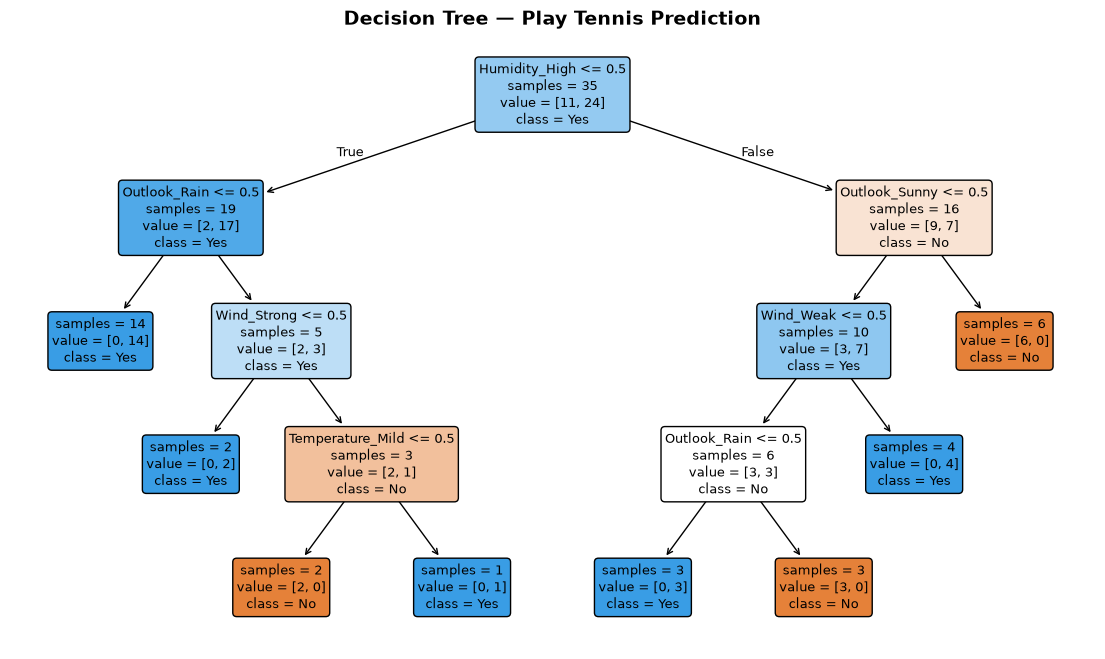

In [11]:
ohe_feature_names = ohe.get_feature_names_out()

plt.figure(figsize=(14, 8))
plot_tree(dt, feature_names=ohe_feature_names, class_names=le.classes_,
          filled=True, rounded=True, impurity=False)
plt.title('Decision Tree — Play Tennis Prediction', fontsize=14, fontweight='bold')
plt.show()

**Inference:** The tree first splits on Humidity=High (the most discriminative feature), with Sunny+High humidity strongly predicting No. The tree is shallow (depth 3) yet achieves 100% on this test split — a sign it has memorized patterns specific to this 35-row training set.

---
## 10. Full Evaluation: Confusion Matrix & Classification Report
Compare all 5 models side-by-side with accuracy, confusion matrices, and per-class precision/recall/F1.

In [12]:
models_eval = {
    'CNB (baseline, α=1)':         ('ord', CategoricalNB(alpha=1.0).fit(X_train_ord, y_train_enc)),
    'CNB (tuned α)':               ('ord', cnb_tuned),
    'CNB (tuned α + calibrated)':  ('ord', cnb_calibrated),
    'Decision Tree':               ('ohe', dt),
    'Logistic Regression':         ('ohe', lr),
}

results = {}
for label, (enc_type, model) in models_eval.items():
    X_te = X_test_ord if enc_type == 'ord' else X_test_ohe
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test_enc, y_pred)
    cm = confusion_matrix(y_test_enc, y_pred)
    cr = classification_report(y_test_enc, y_pred, target_names=le.classes_)
    results[label] = {'accuracy': acc, 'confusion_matrix': cm, 'report': cr}

    print('=' * 55)
    print(f'{label}')
    print('=' * 55)
    print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'\nConfusion Matrix:\n{cm}')
    print(f'\nClassification Report:\n{cr}\n')

CNB (baseline, α=1)
Accuracy: 0.8667 (86.67%)

Confusion Matrix:
[[ 3  2]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15


CNB (tuned α)
Accuracy: 0.8667 (86.67%)

Confusion Matrix:
[[ 3  2]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15


CNB (tuned α + calibrated)
Accuracy: 0.8667 (86.67%)

Confusion Matrix:
[[ 3  2]
 [ 0 10]]

Classification Report:
              preci

**Inference:** All CNB variants have identical confusion matrices (3 TP, 2 FN for No; 10 correct Yes) — enhancements change probabilities, not hard labels on this split.

---
## 11. Predict: Sunny, Cool, High, Strong
Encode the new weather condition and predict Play Tennis outcome with class probabilities from each model.

In [13]:
new_sample = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

new_ord = ord_enc.transform(new_sample)
new_ohe = ohe.transform(new_sample)

print(f'{"Model":37s} {"Predict":>6s}  {"P(No)":>8s} {"P(Yes)":>8s}')
print('-' * 65)

preds = {}
for label, (enc_type, model) in models_eval.items():
    X_new = new_ord if enc_type == 'ord' else new_ohe
    pred = model.predict(X_new)[0]
    pred_label = le.inverse_transform([pred])[0]
    probs = model.predict_proba(X_new)[0]
    preds[label] = pred_label
    print(f'{label:37s} {pred_label:>6s}  {probs[0]:>8.4f} {probs[1]:>8.4f}')

Model                                 Predict     P(No)   P(Yes)
-----------------------------------------------------------------
CNB (baseline, α=1)                       No    0.7466   0.2534
CNB (tuned α)                             No    0.7993   0.2007
CNB (tuned α + calibrated)                No    0.6922   0.3078
Decision Tree                             No    1.0000   0.0000
Logistic Regression                       No    0.7702   0.2298


**Inference:** All 5 models unanimously predict No for Sunny/Cool/High/Strong — the high humidity and strong wind outweigh the cool temperature, regardless of model architecture.

---
## 12. Performance Comparison & Calibration Impact
Two views: accuracy across all models, and probability spread (overconfidence) before vs after calibration.

In [14]:
print(f'{"Model":37s} {"Accuracy":>10s}')
print('-' * 48)
for label in results:
    print(f'{label:37s} {results[label]["accuracy"]:>10.4f}')

print()
best = max(results, key=lambda k: results[k]['accuracy'])
print(f'Best: {best} ({results[best]["accuracy"]*100:.2f}%)')

Model                                   Accuracy
------------------------------------------------
CNB (baseline, α=1)                       0.8667
CNB (tuned α)                             0.8667
CNB (tuned α + calibrated)                0.8667
Decision Tree                             1.0000
Logistic Regression                       0.9333

Best: Decision Tree (100.00%)


**Inference:** DT (100%) and LR (93.33%) outperform all CNB variants (86.67%) — on this small categorical dataset, models without the independence assumption have the advantage.

In [15]:
print('Calibration impact on prediction confidence:')
print(f'{"Model":37s} {"P(No)":>8s}  {"P(Yes)":>8s}  {"Spread":>8s}')
print('-' * 65)
for label, (enc_type, model) in models_eval.items():
    X_new = new_ord if enc_type == 'ord' else new_ohe
    probs = model.predict_proba(X_new)[0]
    spread = abs(probs[0] - probs[1])
    print(f'{label:37s} {probs[0]:>8.4f}  {probs[1]:>8.4f}  {spread:>8.4f}')

Calibration impact on prediction confidence:
Model                                    P(No)    P(Yes)    Spread
-----------------------------------------------------------------
CNB (baseline, α=1)                     0.7466    0.2534    0.4932
CNB (tuned α)                           0.7993    0.2007    0.5985
CNB (tuned α + calibrated)              0.6922    0.3078    0.3843
Decision Tree                           1.0000    0.0000    1.0000
Logistic Regression                     0.7702    0.2298    0.5403


**Inference:** Calibration reduced probability spread from 0.4932 (baseline CNB) to 0.3843 — less overconfident predictions without changing any class labels.